# Lab 4.02 - Bivariate Analysis of Qualitative Data

In [1]:

# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 2 - NBA Salaries

The file NBA.csv contains annual salaries for all NBA basketball players in the season (2008–2009), check whether there is independence between position and salary. To do this, first change any hyphenated position such as C-F to
the first listed, in this case C. (Presumably, this is
the player's primary position.)     
Then remove $ and . in Annual Salary and make Annual Salary categorical with four categories: the first is all salaries below the first quartile, the second is all salaries from the first quartile to the median, and so on.  
First make a plot

Results of the main calculations:
  - χ² ≈ 3.0344
  - p-value = 0.8045
  - We do not reject H0


  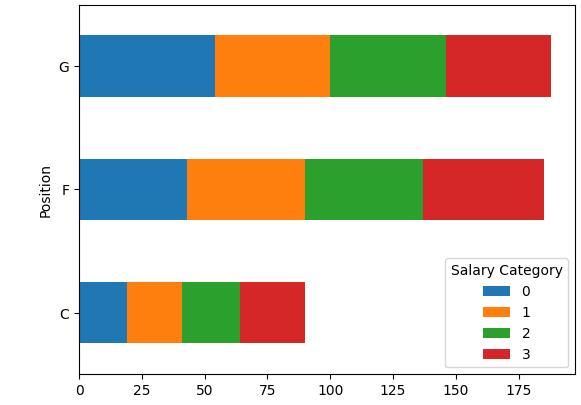

In [36]:
dataset = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/NBA.csv', sep=";")
dataset.head(10)

,Player,Team,Position,Annual Salary,Contract Yrs,Contract Amt,Contract Thru
0,"Bibby, Mike",Atlanta Hawks,G,$14.983.603,1,$14.983.603,2008-09
1,"Johnson, Joe",Atlanta Hawks,G,$14.232.566,5,$70.000.000,2009-10
2,"Smith, Josh",Atlanta Hawks,F,$10.000.000,5,$58.000.000,2012-13
3,"Claxton, Speedy",Atlanta Hawks,G,$5.757.818,4,$25.000.000,2010-11
4,"Williams, Marvin",Atlanta Hawks,F,$5.636.142,4,$18.160.000,2008-09(t)
5,"Horford, Al",Atlanta Hawks,C-F,$4.023.720,3,$12.080.160,2009-10
6,"Pachulia, Zaza",Atlanta Hawks,C,$4.000.000,4,$16.000.000,2008-09
7,"Evans, Maurice",Atlanta Hawks,F-G,$2.500.000,3,$7.500.000,2010-11
8,"Law, Acie",Atlanta Hawks,G,$2.071.680,3,$6.214.920,2009-10
9,"Murray, Ronald",Atlanta Hawks,G,$1.500.000,1,$1.500.000,2008-09


In [37]:
# We doen de chi-squared test omdat het gaat over een onafh kwalit. en afh kwalit veranderlijke
# We voegen loonschaal toe (dit is de 2de veranderlijke)

dataset['Position'] = dataset['Position'].str[0]
dataset.head(10)

,Player,Team,Position,Annual Salary,Contract Yrs,Contract Amt,Contract Thru
0,"Bibby, Mike",Atlanta Hawks,G,$14.983.603,1,$14.983.603,2008-09
1,"Johnson, Joe",Atlanta Hawks,G,$14.232.566,5,$70.000.000,2009-10
2,"Smith, Josh",Atlanta Hawks,F,$10.000.000,5,$58.000.000,2012-13
3,"Claxton, Speedy",Atlanta Hawks,G,$5.757.818,4,$25.000.000,2010-11
4,"Williams, Marvin",Atlanta Hawks,F,$5.636.142,4,$18.160.000,2008-09(t)
5,"Horford, Al",Atlanta Hawks,C,$4.023.720,3,$12.080.160,2009-10
6,"Pachulia, Zaza",Atlanta Hawks,C,$4.000.000,4,$16.000.000,2008-09
7,"Evans, Maurice",Atlanta Hawks,F,$2.500.000,3,$7.500.000,2010-11
8,"Law, Acie",Atlanta Hawks,G,$2.071.680,3,$6.214.920,2009-10
9,"Murray, Ronald",Atlanta Hawks,G,$1.500.000,1,$1.500.000,2008-09


In [38]:
# dollar verwijderen
dataset['Annual Salary'] = dataset['Annual Salary'].str.replace('$', '')
dataset['Annual Salary'] = dataset['Annual Salary'].str.replace('.', '')
dataset['Annual Salary'] = dataset['Annual Salary'].astype(float)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Player         463 non-null    object 
 1   Team           463 non-null    object 
 2   Position       463 non-null    object 
 3   Annual Salary  463 non-null    float64
 4   Contract Yrs   463 non-null    int64  
 5   Contract Amt   463 non-null    object 
 6   Contract Thru  463 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 25.4+ KB


In [39]:
def salary_category(salary):
  q1 = dataset['Annual Salary'].quantile(0.25)
  q2 = dataset['Annual Salary'].quantile(0.5)
  q3 = dataset['Annual Salary'].quantile(0.75)

  if salary < q1:
    return 1
  elif salary < q2:
    return 2
  elif salary < q3:
    return 3
  else:
    return 4

dataset['Salary Category'] = dataset['Annual Salary'].apply(salary_category)

In [41]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Player           463 non-null    object 
 1   Team             463 non-null    object 
 2   Position         463 non-null    object 
 3   Annual Salary    463 non-null    float64
 4   Contract Yrs     463 non-null    int64  
 5   Contract Amt     463 non-null    object 
 6   Contract Thru    463 non-null    object 
 7   Salary Category  463 non-null    int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 29.1+ KB


In [ ]:
# Stap 1
# H0: er is geen verband tussen positief en loonschaal
# H1: er is wel een verband tussen positief en loonschaal

# Stap 2
alpha = 0.05

In [46]:
# Stap 3
# Chi-squared test for independence based on a contingency table
observed = pd.crosstab(dataset['Salary Category'], dataset['Position'])
chi2, p, degree_of_freedom, expected = stats.chi2_contingency(observed)
g = stats.chi2.isf(alpha, df = degree_of_freedom)

print("Chi-squared       : %.4f" % chi2)
print("Degrees of freedom: %d" % degree_of_freedom)
print("P-value           : %.4f" % p)
print("Critical value    : %.4f" % g)

Chi-squared       : 3.0344
Degrees of freedom: 6
P-value           : 0.8045
Critical value    : 12.5916


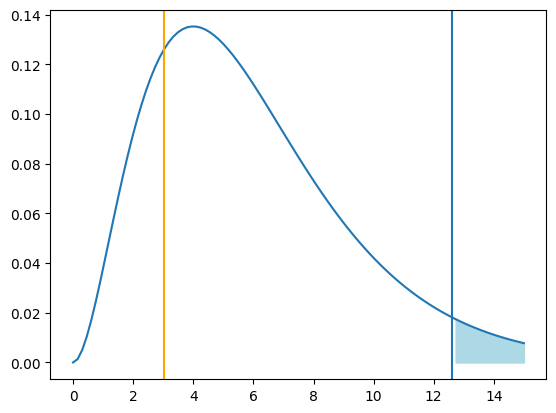

In [47]:
# Is there an association between Gender and Survey?

# x-values:
x = np.linspace(0, 15, num=100)
# probability density of the chi-squared distribution with 6 degrees of freedom
y = stats.chi2.pdf(x, df=degree_of_freedom)
# the number q for which the right tail probability is exactly 5%:
q = stats.chi2.isf(alpha, df=degree_of_freedom)

fig, tplot = plt.subplots(1, 1)
tplot.plot(x, y)                     # probability density
tplot.fill_between(x, y, where=x>=q, # critical area
    color='lightblue')
tplot.axvline(q)                     # critical value
tplot.axvline(chi2, color='orange')  # chi-squared

In [ ]:
# Stap 5
# p = 80% > 5%
# 3.03 < g
# we kunnen h0 niet rejecten